<a href="https://colab.research.google.com/github/beyzadurdu6619/TrustLLM-Uncertainty-Quantification/blob/main/02_numpy_matplotlib_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn.functional as F

# Simülasyon: Modelin bir sonraki kelime için ürettiği ham puanlar (Logitler)
# Kelimeler: ["Ankara", "İstanbul", "İzmir"]
logits_emin = torch.tensor([10.0, 2.0, 1.0])      # Model "Ankara"dan çok emin
logits_kararsiz = torch.tensor([3.1, 3.0, 2.9])  # Model kelimeler arasında kararsız

# Softmax ile Olasılıklara Dönüştürelim
probs_emin = F.softmax(logits_emin, dim=-1)
probs_kararsiz = F.softmax(logits_kararsiz, dim=-1)

print("--- EMİN MODEL OLASILIKLARI ---")
print(f"Ankara: %{probs_emin[0]*100:.2f} | İstanbul: %{probs_emin[1]*100:.2f} | İzmir: %{probs_emin[2]*100:.2f}")

print("\n--- KARARSIZ MODEL OLASILIKLARI ---")
print(f"Ankara: %{probs_kararsiz[0]*100:.2f} | İstanbul: %{probs_kararsiz[1]*100:.2f} | İzmir: %{probs_kararsiz[2]*100:.2f}")

--- EMİN MODEL OLASILIKLARI ---
Ankara: %99.95 | İstanbul: %0.03 | İzmir: %0.01

--- KARARSIZ MODEL OLASILIKLARI ---
Ankara: %36.72 | İstanbul: %33.22 | İzmir: %30.06


In [5]:
import torch

def calculate_entropy(probabilities):
    # Shannon Entropi Formülü: -sum(p * log(p))
    # 1e-9 ekleme sebebi: log(0) hatası almamak (Epsilon)
    return -torch.sum(probabilities * torch.log(probabilities + 1e-9))

entropy_emin = calculate_entropy(probs_emin)
entropy_kararsiz = calculate_entropy(probs_kararsiz)

print(f"Emin Modelin Entropisi (Kararsızlık Skoru)    : {entropy_emin.item():.4f} (Düşük!)")
print(f"Kararsız Modelin Entropisi (Yanılsama Riski) : {entropy_kararsiz.item():.4f} (Yüksek!)")

Emin Modelin Entropisi (Kararsızlık Skoru)    : 0.0043 (Düşük!)
Kararsız Modelin Entropisi (Yanılsama Riski) : 1.0953 (Yüksek!)


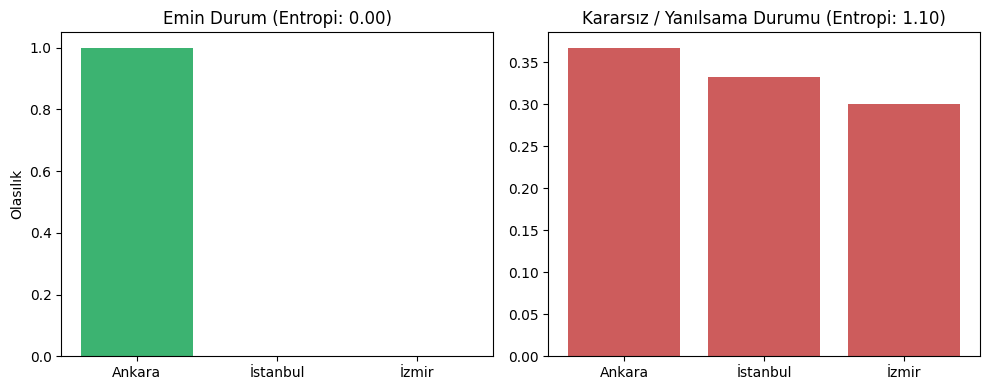

In [6]:
import matplotlib.pyplot as plt

categories = ['Ankara', 'İstanbul', 'İzmir']

plt.figure(figsize=(10, 4))

# Emin Model Grafiği
plt.subplot(1, 2, 1)
plt.bar(categories, probs_emin.numpy(), color='mediumseagreen')
plt.title(f"Emin Durum (Entropi: {entropy_emin:.2f})")
plt.ylabel("Olasılık")

# Kararsız Model Grafiği
plt.subplot(1, 2, 2)
plt.bar(categories, probs_kararsiz.numpy(), color='indianred')
plt.title(f"Kararsız / Yanılsama Durumu (Entropi: {entropy_kararsiz:.2f})")

plt.tight_layout()
plt.show()